In [1]:
import pandas as pd
from ray.rllib.utils.debug import summarize


In [ ]:
from data_functions import load_vdem
v_dem_df = load_vdem()



In [ ]:
print("Rows:", len(v_dem_df))
print("Columns:", len(v_dem_df.columns))
print("Columns available:", v_dem_df.columns.tolist())

In [ ]:
print("Rows:", len(maddison_df))
print("Columns:", len(maddison_df.columns))
print("Columns available:", maddison_df.columns.tolist())

In [ ]:
maddison_df[maddison_df["country"] == "Germany"]


In [ ]:
v_dem_df[v_dem_df["country_name"] == "Germany"][["country_name", "year", "v2x_regime"]]


In [ ]:
# Delete all observations before the 1900s and all observations after 2022 for the v-dem data

v_dem_df = v_dem_df[(v_dem_df["year"] >= 1900) & (v_dem_df["year"] <= 2022)]


In [ ]:
v_dem_df[v_dem_df["country"] == "Germany"]

In [ ]:
# Delete all observations before the 1900s and all observations after 2022 for the maddison data
maddison_df = maddison_df[(maddison_df["year"] >= 1900) & (maddison_df["year"] <= 2022)]


In [ ]:
maddison_df[(maddison_df["country"] == "Germany")]


In [ ]:
from data_functions import load_maddison
from data_functions import load_vdem

In [ ]:
v_dem_df = load_vdem()

In [ ]:
maddison_df = load_maddison()

In [ ]:
print(v_dem_df["country_name"].unique())

print(maddison_df["country"].unique())


In [ ]:
print(matches)

In [ ]:

#  Former USSR,Somaliland, Somalia, Turkey, Dominica are missing from either datasets
#  State of Palestine >> Palestine/west bank - Palestine/Gaza

In [ ]:
# Matches all the names in both datasest to be able to merge both dataframes
v_dem_df["country_name"].replace({
    "Bolivia (Plurinational State of)": "Bolivia",
    "D.R. of the Congo": "Democratic Republic of the Congo",
    "Iran": "Iran (Islamic Republic of)",
    "Burma/Myanmar" : "Myanmar",
    "Ivory Coast":"Côte d'Ivoire",
    "Czechia":"Czech Republic"
}, inplace=True)

maddison_df["country"].replace({
    "The Gambia": "Gambia",
    "United States": "United States of America",
    "Lao People's DR": "Laos",
    "Republic of Moldova" : "Moldova",
    "Russian Federation" : "Russia",
    "Sudan (Former)" : "Sudan",
    "Syrian Arab Republic" :"Syria",
    "Taiwan, Province of China" : "Taiwan",
    "Cabo Verde":"Cape Verde",
    "Swaziland":"Eswatini",
    "Congo":"Republic of the Congo",
    "China, Hong Kong SAR" : "Hong Kong",
    "D.P.R. of Korea":"North Korea",
    "Republic of Korea" : "South Korea",
    "U.R. of Tanzania: Mainland":"Tanzania",
    "Venezuela (Bolivarian Republic of)":" Venezuela",
    "Viet Nam":"Vietnam"
     #Zanzibar is excluded from the v_dem data set and is added as a seperate country


}, inplace=True)

In [ ]:
v_dem_df[v_dem_df["country_name"] == "Bolivia"]

In [ ]:
v_dem_df.rename(columns={"country_name": "country"}, inplace=True)

In [ ]:
# Merge both data sets
merged_df = pd.merge(v_dem_df, maddison_df, on=["country", "year"], how="inner")  # inner join keeps only matching rows
merged_df

In [ ]:
merged_df[["country", "year", "v2x_regime", "region", "gdppc", "pop" ]][merged_df['country'] == "Germany"]


In [ ]:
print("Rows:", len(merged_df))
print("Columns:", len(merged_df.columns))
print("Columns available:", merged_df.columns.tolist())
print((len(maddison_df["country"].unique())))


In [ ]:
from data_functions import load_lag_gdppc, load_inf_mor, load_hc, load_popgrowth_df, load_TFP, load_vdem_corr, load_trade_share, load_eth_frac, load_gov_exp, load_tax_rev, load_maddison, load_vdem

In [ ]:
# ================================================================
# 1. IMPORT REQUIRED LIBRARIES AND FUNCTIONS
# ================================================================
import country_converter as coco
import pandas as pd
from data_functions import (
    load_lag_gdppc, load_inf_mor, load_hc, load_popgrowth_df,
    load_TFP, load_vdem_corr, load_trade_share, load_eth_frac,
    load_gov_exp, load_tax_rev, load_maddison, load_vdem
)
#from fuzzywuzzy import process  # Required for fuzzy matching

# ================================================================
# 2. DEFINE FUNCTION TO STANDARDIZE COUNTRY NAMES
# ================================================================
def standardize_country_names(df, country_col='country'):
    """
    Standardizes country names to ISO3 codes.

    Steps:
    1. Automatic conversion using coco.convert()
    2. Identify unmatched country names
    3. Attempt fuzzy matching for unmatched names
    4. Replace original country column with standardized ISO3 codes
    """
    # Step 1: Automatic conversion
    df['iso3'] = coco.convert(names=df[country_col], to='ISO3', not_found=None)

    # Step 2: Identify unmatched names
    unmatched = df[df['iso3'].isna()][country_col].unique()


#Step 3: Fuzzy matching for unmatched names
    coco_names = coco.CountryConverter().data['name_short'].tolist()
    fixes = {}
    for name in unmatched:
        match, score = process.extractOne(name, coco_names)
        if score > 85:
            fixes[name] = match  # Accept match if good enough

# Apply fixes using mapping + conversion
    df['iso3'] = df['iso3'].fillna(
        df[country_col].replace(fixes).map(
            lambda x: coco.convert(names=x, to='ISO3', not_found="None")
        )
    )

    # Step 4: Clean up dataframe
    df = df.drop(columns=[country_col])
    df = df.rename(columns={'iso3': 'country'})

    return df

# =====================================================================================
# 3. APPLY FUNCTION TO THE DESIRED DATAFRAME --> SAVE THE RESULTS AS A CSV FILES
# =====================================================================================
gross_cap_for_df = standardize_country_names(gross_cap_for_df)

# ================================================================
# 4. RUN ISO3 CONVERSION AND STORE RESULTS
# ================================================================
converted = pd.Series(
    coco.convert(names=gross_cap_for_df['country'], to='ISO3', not_found='not found'),
    index=gross_cap_for_df.index
)

# ================================================================
# 5. IDENTIFY UNMATCHED ROWS
# ================================================================
unmatched_mask = (converted == 'not found') | (converted.isna())
unmatched = gross_cap_for_df.loc[unmatched_mask, 'country'].unique()

print("Unmatched country names:")
print(unmatched)


Africa Eastern and Southern not found in regex
Africa Western and Central not found in regex
Arab World not found in regex
Central Europe and the Baltics not found in regex
Channel Islands not found in regex
Caribbean small states not found in regex
East Asia & Pacific ( not found in regex
Early-demographic dividend not found in regex
East Asia & Pacific not found in regex
Europe & Central Asia ( not found in regex
Europe & Central Asia not found in regex
Euro area not found in regex
European Union not found in regex
Fragile and conflict affected situations not found in regex
High income not found in regex
Heavily indebted poor countries (HIPC) not found in regex
IBRD only not found in regex
IDA & IBRD total not found in regex
IDA total not found in regex
IDA blend not found in regex
IDA only not found in regex
Not classified not found in regex
Latin America & Caribbean ( not found in regex
Latin America & Caribbean not found in regex
Least developed countries: UN classification not fo

In [18]:
import pandas as pd
import country_converter as coco
from rapidfuzz import process

def safe_iso3(value):
    """Ensure the return value is always a string or None."""
    if isinstance(value, list):
        return value[0] if len(value) > 0 else None
    if isinstance(value, str):
        return value
    return None

def standardize_country_names(df, country_col='country'):
    cc = coco.CountryConverter()

    # Step 1: initial conversion
    df['iso3'] = df[country_col].apply(
        lambda x: safe_iso3(cc.convert(names=x, to='ISO3', not_found=None))
    )

    # Step 2: find unmatched
    unmatched = df[df['iso3'].isna()][country_col].unique()

    # List of known country names for fuzzy match
    coco_names = cc.data['name_short'].tolist()

    # Step 3: fuzzy match unmatched names
    fixes = {}
    for name in unmatched:
        match, score, _ = process.extractOne(name, coco_names)
        if score > 85:
            fixes[name] = match

    # Step 4: apply fixes and reconvert
    df['iso3'] = df['iso3'].fillna(
        df[country_col].replace(fixes).apply(
            lambda x: safe_iso3(cc.convert(names=x, to='ISO3', not_found=None))
        )
    )

    # Step 5: Clean up
    df = df.drop(columns=[country_col])
    df = df.rename(columns={'iso3': 'country'})

    return df


In [21]:
gross_cap_for_df = standardize_country_names(gross_cap_for_df)


Africa Eastern and Southern not found in regex
Africa Western and Central not found in regex
Arab World not found in regex
Central Europe and the Baltics not found in regex
Channel Islands not found in regex
Caribbean small states not found in regex
East Asia & Pacific ( not found in regex
Early-demographic dividend not found in regex
East Asia & Pacific not found in regex
Europe & Central Asia ( not found in regex
Europe & Central Asia not found in regex
Euro area not found in regex
European Union not found in regex
Fragile and conflict affected situations not found in regex
High income not found in regex
Heavily indebted poor countries (HIPC) not found in regex
IBRD only not found in regex
IDA & IBRD total not found in regex
IDA total not found in regex
IDA blend not found in regex
IDA only not found in regex
Not classified not found in regex
Latin America & Caribbean ( not found in regex
Latin America & Caribbean not found in regex
Least developed countries: UN classification not fo

In [22]:
gross_cap_for_df

,indicator,year,Gross capital formation (% of GDP),country
0,Gross capital formation (% of GDP),1970,NaN,ABW
1,Gross capital formation (% of GDP),1970,NaN,Africa Eastern and Southern
2,Gross capital formation (% of GDP),1970,NaN,AFG
3,Gross capital formation (% of GDP),1970,NaN,Africa Western and Central
4,Gross capital formation (% of GDP),1970,NaN,AGO
...,...,...,...,...
14625,Gross capital formation (% of GDP),2024,33.796942,XKX
14626,Gross capital formation (% of GDP),2024,NaN,YEM
14627,Gross capital formation (% of GDP),2024,13.942203,ZAF
14628,Gross capital formation (% of GDP),2024,NaN,ZMB


In [23]:
gross_cap_for_df.to_csv("gross_cap_for_df.csv")

In [6]:
from data_functions import load_trade_share

In [10]:
trade_share_df['country'] = trade_share_df['country'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x
)


In [13]:
trade_share_df

INDICATOR,year,"Exports of goods, Free on board (FOB), US dollar","Imports of goods, Cost insurance freight (CIF), US dollar",export_share,country
0,1948,35391.100000,38855.950000,0.476667,Advanced Economies
1,1949,36919.000000,39108.230000,0.485602,Advanced Economies
2,1950,36361.700000,40278.730000,0.474445,Advanced Economies
3,1951,52632.900000,54785.140000,0.489982,Advanced Economies
4,1952,50413.200000,53551.110000,0.484909,Advanced Economies
...,...,...,...,...,...
12984,2018,3531.595547,7542.572349,0.318904,ZWE
12985,2019,3642.864845,6268.184894,0.367556,ZWE
12986,2020,4394.811685,7021.975998,0.384943,ZWE
12987,2021,6036.187305,9112.979255,0.398450,ZWE


In [7]:
trade_share_df = load_trade_share()

In [ ]:
# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================
import pandas as pd
import glob
from functools import reduce

# ================================================================
# 2. FIND ALL CSV FILES IN THE DIRECTORY
# ================================================================
files = glob.glob("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/*.csv")

# ================================================================
# 3. READ ALL CSV FILES INTO A LIST OF DATAFRAMES
# ================================================================
dfs = []
for f in files:
    df = pd.read_csv(f)

    # ------------------------------------------------------------
    # 3a. Drop all 'Unnamed: ...' columns (often leftover indices)
    # ------------------------------------------------------------
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # ------------------------------------------------------------
    # 3b. Drop all '<anonymous>' columns
    # ------------------------------------------------------------
    df = df.loc[:, df.columns != '<anonymous>']

    # ------------------------------------------------------------
    # 3c. Keep only Country, Year, and the indicator
    #     (all other columns except country/year)
    # ------------------------------------------------------------
    keep_cols = ['country', 'year'] + [c for c in df.columns if c not in ['country', 'year']]
    df = df[keep_cols]

    # Append cleaned df to the list
    dfs.append(df)

# ================================================================
# 4. MERGE ALL DATAFRAMES ON COUNTRY + YEAR
#    Using outer join to preserve all data
# ================================================================
merged_df = reduce(
    lambda left, right: pd.merge(left, right, on=["country", "year"], how="outer"),
    dfs
)

# ================================================================
# 5. SORT MERGED DATAFRAME BY COUNTRY AND YEAR
# ================================================================
merged_df = merged_df.sort_values(["country", "year"]).reset_index(drop=True)



# ================================================================
# 6. LIST OF ROWS TO REMOVE THAT ARE NOT COUNTRIES
# ================================================================
rows_to_remove = [
    "Africa (UN)",
    "Africa Eastern and Southern",
    "Africa Western and Central",
    "Arab World",
    "Asia (UN)",
    "Caribbean small states",
    "Central Europe and the Baltics",
    "Channel Islands",
    "Congo (the)",
    "D.R. of the Congo",
    "Data from database: World Development Indicators",
    "Early-demographic dividend",
    "East Asia & Pacific",
    "East Asia & Pacific (",
    "East Asia & Pacific (IDA & IBRD countries)",
    "Euro area",
    "Europe & Central Asia",
    "Europe & Central Asia (",
    "Europe & Central Asia (IDA & IBRD countries)",
    "Europe (UN)",
    "European Union",
    "Former USSR",
    "Former Yugoslavia",
    "Fragile and conflict affected situations",
    "German Democratic Republic",
    "Heavily indebted poor countries (HIPC)",
    "High income",
    "High-income countries",
    "IBRD only",
    "IDA & IBRD total",
    "IDA blend",
    "Last Updated: 10/07/2025",
    "Latin America and the Caribbean (UN)",
    "Least developed countries",
    "Less developed regions",
    "Less developed regions, ",
    "Low-income countries",
    "Lower-middle-income countries",
    "More developed regions",
    "Northern America (UN)",
    "Oceania (UN)",
    "Republic of Vietnam",
    "Upper-middle-income countries",
    "World",
    "Zanzibar",
    "AIA",
    "BES",
    "BLM",
    "COK",
    "ESH",
    "FLK",
    "GGY",
    "GLP",
    "GUF",
    "JEY",
    "MSR",
    "MTQ",
    "MYT",
    "NIU",
    "REU",
    "SHN",
    "SPM",
    "TKL",
    "VAT",
    "WLF"
]

# Remove the specified rows from your dataframe
merged_df = merged_df[~merged_df['country'].isin(rows_to_remove)]

# ================================================================
# 6. SAVE MERGED DATAFRAME TO CSV
# ================================================================
merged_df.to_csv("merged_dataset.csv", index=False)

# ================================================================
# 7. OPTIONAL: READ BACK THE MERGED CSV
# ================================================================
merged_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/merged_df.csv")


In [473]:
merged_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/df_merged_new.csv")


In [474]:
cols_to_drop = [
    "General government final consumption expenditure (% of GDP)",
    "v2x_polyarchy",
    "v2x_liberal",
    'pop',
    "Tax revenue (% of GDP)",
    'Gross capital formation (% of GDP)',
    "hc",
    "rtfpna"
    ]

merged_df = merged_df.replace({"(..)": np.nan, "..": np.nan})
merged_df = merged_df.drop(columns=cols_to_drop)
merged_df = merged_df.drop_duplicates(subset=['country', 'year'], keep='first')



In [440]:
merged_df.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'country', 'year',
       'gdp_pc_lag1', 'Mortality rate, infant (per 1,000 live births)',
       'fe_etfra', 'gdppc', 'v2x_regime',
       'Population growth rate - Sex: all - Age: all - Variant: estimates',
       'v2x_corr', 'v2x_execorr', 'v2x_pubcorr', 'export_share'],
      dtype='object')

In [397]:
merged_df.columns

Index(['Unnamed: 0.2', 'Unnamed: 0.1', 'Unnamed: 0', 'country', 'year',
       'gdp_pc_lag1', 'Mortality rate, infant (per 1,000 live births)',
       'fe_etfra', 'gdppc', 'v2x_regime',
       'Population growth rate - Sex: all - Age: all - Variant: estimates',
       'v2x_corr', 'v2x_execorr', 'v2x_pubcorr', 'export_share',
       'Gross capital formation (% of GDP)'],
      dtype='object')

In [363]:
merged_df

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,country,year,gdp_pc_lag1,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,v2x_regime,Tax revenue (% of GDP),Population growth rate - Sex: all - Age: all - Variant: estimates,v2x_corr,v2x_execorr,v2x_pubcorr,export_share,Gross capital formation (% of GDP)
0,0,0,0,ABW,1950,NaN,NaN,NaN,NaN,NaN,NaN,2.546,NaN,NaN,NaN,NaN,NaN
1,1,1,1,ABW,1951,NaN,NaN,NaN,NaN,NaN,NaN,2.627,NaN,NaN,NaN,NaN,NaN
2,2,2,2,ABW,1952,NaN,NaN,NaN,NaN,NaN,NaN,2.643,NaN,NaN,NaN,NaN,NaN
3,3,3,3,ABW,1953,NaN,NaN,NaN,NaN,NaN,NaN,2.688,NaN,NaN,NaN,NaN,NaN
4,4,4,4,ABW,1954,NaN,NaN,NaN,NaN,NaN,NaN,2.640,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18136,18136,17930,20855,ZWE,2019,1900.199191,46,0.3662,1753.024449,1.0,..,1.609,0.765,0.786,0.789,0.367556,13.799402
18137,18137,17931,20856,ZWE,2020,1753.024449,44.9,0.3662,1585.972804,1.0,..,1.709,0.795,0.772,0.795,0.384943,13.146075
18138,18138,17932,20857,ZWE,2021,1585.972804,43.6,0.3662,1687.253154,1.0,..,1.743,0.826,0.732,0.846,0.398450,15.507058
18139,18139,17933,20858,ZWE,2022,1687.253154,42.2,0.3662,1703.529373,1.0,..,1.670,0.806,0.763,0.852,0.402938,14.610339


In [345]:
merged_df.to_excel("merged_df.xlsx")

In [115]:
merged_df.to_excel("merged_df.xlsx")

In [221]:
len(merged_df)
merged_df.nunique()

Unnamed: 0.2                                                         18141
Unnamed: 0.1                                                         17935
Unnamed: 0                                                           17935
country                                                                237
year                                                                    74
gdp_pc_lag1                                                           7943
rtfpna                                                                6295
Mortality rate, infant (per 1,000 live births)                        1746
fe_etfra                                                               153
gdppc                                                                 8010
pop                                                                   8596
v2x_regime                                                               4
hc                                                                    8545
Population growth rate - 

In [61]:
len(merged_df)

18141

In [15]:
import numpy as np

In [205]:
# ================================================================
# 1. This is extra to see the missing countries etc. ( DO NOT RUN)
# ================================================================


# ================================================================
# 1. MISSING VALUES PER COLUMN
# ================================================================
missing_per_column = merged_df.isna().sum()
print("Missing values per column:")
print(missing_per_column)


# ================================================================
# 2. MISSING VALUES PER COUNTRY
# ================================================================
missing_per_country = clean_merged_df.groupby('country').apply(lambda x: x.isna().mean())
print("\nMissing fraction per country:")
print(missing_per_country)

# ================================================================
# 3. DISPLAY SETTINGS FOR FULL OUTPUT
# ================================================================
import pandas as pd

pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.max_colwidth', None)  # Show full column width

# Re-print missing per country with full display
print("\nMissing fraction per country (full display):")
print(missing_per_country)

# Save to CSV
missing_per_country.to_csv("missing_per_country.csv")


# ================================================================
# 4. MISSING VALUES PER YEAR
# ================================================================
missing_per_year = merged_df.groupby('year').apply(lambda x: x.isna().mean())
print("\nMissing fraction per year:")
print(missing_per_year)

# Re-print with full display
print("\nMissing fraction per year (full display):")
print(missing_per_year)

# Save to CSV
missing_per_year.to_csv("missing_per_year.csv")


# ================================================================
# 5. REMOVE COUNTRIES WITH TOO FEW VALID YEARS
#    Drop countries with <20 non-missing rows for any variable
# ================================================================
import numpy as np

# Select all indicator variables (everything except country/year)
all_vars = [c for c in clean_merged_df.columns if c not in ["country", "year"]]

# Count how many rows have at least SOME data (not all NaN)
country_valid_years = merged_df.groupby("country")[all_vars].apply(
    lambda df: df.dropna(how="all").shape[0]
)

# Identify countries with fewer than 20 valid years
countries_small = country_valid_years[country_valid_years < 20].index.tolist()

print("\nCountries to drop due to <20 valid years:")
print(countries_small)


Missing values per column:
Unnamed: 0.2                                                             0
Unnamed: 0.1                                                             0
Unnamed: 0                                                               0
country                                                                  0
year                                                                     0
gdp_pc_lag1                                                           9104
Mortality rate, infant (per 1,000 live births)                        3934
fe_etfra                                                              8144
gdppc                                                                 9086
pop                                                                   8923
v2x_regime                                                            5432
hc                                                                    9474
Population growth rate - Sex: all - Age: all - Variant: estimates      18

NameError: name 'clean_merged_df' is not defined

In [347]:
# ================================================================
# 1. INITIAL YEAR FILTER (1970–2023)
#    This line filters the dataframe but does not assign the result
# ================================================================
#merged_df[(merged_df['year'] >= 2000) & (merged_df['year'] <= 2023)]

# ================================================================
# 2. REPLACE NON-NUMERIC MISSING LABELS WITH NaN
# ================================================================
merged_df = merged_df.replace({"(..)": np.nan, "..": np.nan})

# ================================================================
# 3. FINAL YEAR FILTER (1960–2023)
# ================================================================
merged_df_new = merged_df[(merged_df['year'] >= 1950) & (merged_df['year'] <= 2024)]

# ================================================================
# 4. IDENTIFY COUNTRIES WITH >x% MISSING DATA
# ================================================================
missing_per_country = merged_df_new.groupby("country").apply(
    lambda x: x.isna().mean().mean()
)
# Countries with more than x% missing data
countries_to_drop = missing_per_country[missing_per_country > 0.7].index.tolist() # the lower the %  the more countries we drop

print("Countries to drop:", countries_to_drop)
print(len(countries_to_drop))

# Remove them
clean_merged_df_new = merged_df_new[
    ~merged_df_new["country"].isin(countries_to_drop)
]
print(clean_merged_df_new.nunique())

Countries to drop: []
0
Unnamed: 0.2                                                         18141
Unnamed: 0.1                                                         17935
Unnamed: 0                                                           17935
country                                                                237
year                                                                    74
gdp_pc_lag1                                                           7943
rtfpna                                                                6295
Mortality rate, infant (per 1,000 live births)                        1745
fe_etfra                                                               153
gdppc                                                                 8010
v2x_regime                                                               4
hc                                                                    8545
Population growth rate - Sex: all - Age: all - Variant: estimates     5728
v

/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_29355/567457721.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_per_country = merged_df_new.groupby("country").apply(


In [234]:
clean_merged_df_new.to_csv("clean_merged_df_new.csv")

In [189]:
len(clean_merged_df_new)
clean_merged_df_new.nunique()

Unnamed: 0.2                                                         10843
Unnamed: 0.1                                                         10675
Unnamed: 0                                                           10675
country                                                                237
year                                                                    44
gdp_pc_lag1                                                           6868
Mortality rate, infant (per 1,000 live births)                        1338
fe_etfra                                                               153
gdppc                                                                 6921
pop                                                                   7013
v2x_regime                                                               4
hc                                                                    5599
Population growth rate - Sex: all - Age: all - Variant: estimates     4802
v2x_corr                 

In [217]:
len(clean_merged_df_new)


18141

In [425]:
import pandas as pd
import numpy as np

def trim_by_full_availability(df, country_col="country", year_col="year"):
    data_cols = df.columns.difference([country_col, year_col])

    def trim_country(g):
        # Identify years where ALL variables are non-missing
        full_available = g[data_cols].notna().all(axis=1)

        # If no fully-available years exist, drop country completely
        if not full_available.any():
            return pd.DataFrame(columns=g.columns)

        # First & last year with all variables available
        start_year = g.loc[full_available, year_col].min()
        end_year   = g.loc[full_available, year_col].max()

        # Keep the entire interval (start_year..end_year)
        return g[(g[year_col] >= start_year) & (g[year_col] <= end_year)]

    # Apply to each country
    trimmed = df.groupby(country_col, group_keys=False).apply(trim_country)

    return trimmed.reset_index(drop=True)


In [475]:
Final_df = trim_by_full_availability(merged_df)

/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_29355/324325717.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trimmed = df.groupby(country_col, group_keys=False).apply(trim_country)
/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_29355/324325717.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trimmed = df.groupby(country_col, group_keys=False).apply(trim_country)


In [476]:
len(Final_df)

6866

In [463]:
Final_df["country"].unique()


array(['AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT', 'AZE',
       'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BIH', 'BLR',
       'BOL', 'BRA', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV',
       'CMR', 'COL', 'CRI', 'CUB', 'CYP', 'CZE', 'DEU', 'DJI', 'DNK',
       'DOM', 'DZA', 'ECU', 'EGY', 'ESP', 'EST', 'ETH', 'FIN', 'FRA',
       'GAB', 'GBR', 'GEO', 'GHA', 'GIN', 'GMB', 'GNB', 'GRC', 'GTM',
       'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'IRN', 'IRQ',
       'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM',
       'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LKA', 'LSO', 'LTU',
       'LVA', 'MAR', 'MDA', 'MDG', 'MEX', 'MKD', 'MLI', 'MMR', 'MNG',
       'MOZ', 'MRT', 'MUS', 'MWI', 'MYS', 'NAM', 'NER', 'NGA', 'NIC',
       'NLD', 'NOR', 'NPL', 'NZL', 'OMN', 'PAK', 'PAN', 'PER', 'PHL',
       'POL', 'PRK', 'PRT', 'PRY', 'ROU', 'RUS', 'RWA', 'SAU', 'SDN',
       'SEN', 'SGP', 'SLE', 'SLV', 'SVK', 'SVN', 'SWE', 'SWZ', 'SYR',
       'TCD', 'TGO',

In [452]:
len(df_unique)

6866

In [458]:
Final_df.to_csv("Final_df.csv")

In [451]:
df_unique = Final_df.drop_duplicates(subset=['country', 'year'], keep='first')

In [308]:
merged_df.nun

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,country,year,gdp_pc_lag1,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,pop,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,v2x_corr,v2x_execorr,v2x_pubcorr,export_share
0,0,0,0,ABW,1950,NaN,NaN,NaN,NaN,NaN,NaN,2.546,NaN,NaN,NaN,NaN
1,1,1,1,ABW,1951,NaN,NaN,NaN,NaN,NaN,NaN,2.627,NaN,NaN,NaN,NaN
2,2,2,2,ABW,1952,NaN,NaN,NaN,NaN,NaN,NaN,2.643,NaN,NaN,NaN,NaN
3,3,3,3,ABW,1953,NaN,NaN,NaN,NaN,NaN,NaN,2.688,NaN,NaN,NaN,NaN
4,4,4,4,ABW,1954,NaN,NaN,NaN,NaN,NaN,NaN,2.640,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18136,18136,17930,20855,ZWE,2019,1900.199191,46,0.3662,1753.024449,14344.59,1.0,1.609,0.765,0.786,0.789,0.367556
18137,18137,17931,20856,ZWE,2020,1753.024449,44.9,0.3662,1585.972804,14614.82,1.0,1.709,0.795,0.772,0.795,0.384943
18138,18138,17932,20857,ZWE,2021,1585.972804,43.6,0.3662,1687.253154,14900.01,1.0,1.743,0.826,0.732,0.846,0.398450
18139,18139,17933,20858,ZWE,2022,1687.253154,42.2,0.3662,1703.529373,15204.66,1.0,1.670,0.806,0.763,0.852,0.402938


In [197]:

# ================================================================
# 6. SELECT ALL VARIABLES EXCEPT COUNTRY/YEAR
# ================================================================
all_vars = [c for c in clean_merged_df_new.columns if c not in ["country", "year"]]

# ================================================================
# 7. COUNT NON-MISSING YEARS PER COUNTRY PER VARIABLE
# ================================================================
non_missing_counts = clean_merged_df_new.groupby("country")[all_vars].apply(
    lambda df: df.notna().sum()
)

print(non_missing_counts)

# ================================================================
# 8. BOOLEAN: TRUE IF A COUNTRY HAS ≥50 YEARS OF DATA FOR A VARIABLE
# ================================================================
valid_50years = non_missing_counts >= 35

print(valid_50years)

# ================================================================
# 9. FIRST FILTER: KEEP COUNTRIES WITH ANY VARIABLE HAVING ≥50 YEARS
# ================================================================
countries_keep = valid_50years.any(axis=1)

clean_df = clean_merged_df_new[
    clean_merged_df_new['country'].isin(countries_keep.index[countries_keep])
]

# ================================================================
# 10. SECOND FILTER:
#     KEEP COUNTRIES WITH ≥50 YEARS FOR AT LEAST 70% OF VARIABLES
# ================================================================
countries_keep = (valid_50years.sum(axis=1) / len(all_vars)) >= 0.6

clean_df = clean_merged_df_new[
    clean_merged_df_new['country'].isin(countries_keep.index[countries_keep])
]

# ================================================================
# 11. FIND COLUMNS WITH >60% MISSING VALUES
# ================================================================
missing_fraction = clean_df.isna().mean()


col_missing = missing_fraction[missing_fraction > 0.4].index.tolist()

print("Columns with >60% missing data:")
print(col_missing)


         Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0  gdp_pc_lag1  \
country                                                        
ABW                41            41          41            0   
AFG               164           164         164          164   
AGO                41            41          41           41   
AIA                41            41          41            0   
ALB                41            41          41           41   
...               ...           ...         ...          ...   
XKX                41            41          41            0   
YEM               110           110         110          110   
ZAF                41            41          41           41   
ZMB                41            41          41           41   
ZWE                41            41          41           41   

         Mortality rate, infant (per 1,000 live births)  gdppc  pop  \
country                                                               
ABW                      

In [161]:
clean_df.nunique()



Unnamed: 0.2                                                         4506
Unnamed: 0.1                                                         4434
Unnamed: 0                                                           4434
country                                                               177
year                                                                   24
gdp_pc_lag1                                                          3791
rtfpna                                                               2224
Mortality rate, infant (per 1,000 live births)                        870
fe_etfra                                                              153
gdppc                                                                3791
pop                                                                  3753
v2x_regime                                                              4
hc                                                                   2820
Population growth rate - Sex: all - Ag

In [198]:
len(clean_df)

6843

In [199]:
clean_df.to_excel("clean_df.xlsx")

In [130]:
missing_summary = pd.DataFrame({
    'missing_count': clean_df.isnull().sum(),
    'missing_percent': clean_df.isnull().mean() * 100
})

print(missing_summary)


                                                    missing_count  \
Unnamed: 0.2                                                    0   
Unnamed: 0.1                                                    0   
Unnamed: 0                                                      0   
country                                                         0   
year                                                            0   
gdp_pc_lag1                                                  1072   
Mortality rate, infant (per 1,000 live births)                580   
fe_etfra                                                     1973   
gdppc                                                        1055   
pop                                                           907   
v2x_regime                                                    556   
hc                                                           3115   
Population growth rate - Sex: all - Age: all - ...            175   
v2x_corr                          

In [346]:
missing_percent = merged_df.isnull().mean() * 100
print(missing_percent)

Unnamed: 0.2                                                          0.000000
Unnamed: 0.1                                                          0.000000
Unnamed: 0                                                            0.000000
country                                                               0.000000
year                                                                  0.000000
gdp_pc_lag1                                                          50.184665
rtfpna                                                               64.224684
Mortality rate, infant (per 1,000 live births)                       21.685684
fe_etfra                                                             44.892784
gdppc                                                                50.085442
v2x_regime                                                           29.943223
hc                                                                   52.224243
Population growth rate - Sex: all - Age: all - Varia

In [123]:
len(clean_df)

8996

In [133]:
# Assume df_filtered is your current cleaned dataframe

# 1. List all variables except country/year
all_vars = [c for c in clean_df.columns if c not in ["country", "year"]]

# 2. Find countries to drop
countries_to_drop = []

for country, group in clean_df.groupby("country"):
    # Check if any variable is completely missing for this country
    if (group[all_vars].isna().all()).any():
        countries_to_drop.append(country)

# 3. Drop these countries
df_filtered_final = clean_df[~clean_df["country"].isin(countries_to_drop)]

print("Dropped countries:", countries_to_drop)
print("Remaining countries:", df_filtered_final['country'].nunique())
len(df_filtered_final)


Dropped countries: ['AFG', 'AZE', 'BLR', 'BLZ', 'BRB', 'BTN', 'COD', 'COG', 'COM', 'CPV', 'CUB', 'DJI', 'DMA', 'ERI', 'FJI', 'GEO', 'GIN', 'GNB', 'GNQ', 'GUY', 'HKG', 'ISL', 'LBN', 'LBR', 'LBY', 'LCA', 'LUX', 'MDV', 'MKD', 'MLT', 'MMR', 'MWI', 'NGA', 'OMN', 'PNG', 'PRI', 'PRK', 'PSE', 'QAT', 'SLB', 'SOM', 'SRB', 'STP', 'SUR', 'SYC', 'SYR', 'TCD', 'TKM', 'TWN', 'UZB', 'VUT', 'YEM']
Remaining countries: 122


6747

In [134]:
df_filtered_final.to_excel("df_filtered_final.xlsx")

In [124]:
clean_df.to_excel("clean_df.xlsx")

In [22]:
df_merged_new.to_excel("df_merged_new.xlsx")


In [1]:
import pandas as pd
import numpy as np

In [19]:
gross_cap_for_df = pd.read_excel("/Users/ghadaelhusseini/Documents/Kassel University Masters /Thesis/my_Data/CAP_formation.xlsx")

In [52]:
gross_cap_for_df

,country,indicator,year,Gross capital formation (% of GDP)
0,Aruba,Gross capital formation (% of GDP),1970,NaN
1,Africa Eastern and Southern,Gross capital formation (% of GDP),1970,NaN
2,Afghanistan,Gross capital formation (% of GDP),1970,NaN
3,Africa Western and Central,Gross capital formation (% of GDP),1970,NaN
4,Angola,Gross capital formation (% of GDP),1970,NaN
...,...,...,...,...
14625,Kosovo,Gross capital formation (% of GDP),2024,33.796942
14626,"Yemen, Rep.",Gross capital formation (% of GDP),2024,NaN
14627,South Africa,Gross capital formation (% of GDP),2024,13.942203
14628,Zambia,Gross capital formation (% of GDP),2024,NaN


In [20]:
# Convert all column names to string
gross_cap_for_df.columns = gross_cap_for_df.columns.map(str)


# 1. Identify year columns
year_cols = [col for col in gross_cap_for_df.columns if col.isdigit()]

# 2. Melt
gross_cap_for_df = gross_cap_for_df.melt(
    id_vars=['Country Name', 'Indicator Name'],
    value_vars=year_cols,
    var_name='year',
    value_name='Value'
)

# 3. Rename columns
gross_cap_for_df = gross_cap_for_df.rename(columns={
    "Country Name": "country",
    "Indicator Name": "indicator"
})

# 4. Keep only needed columns
gross_cap_for_df = gross_cap_for_df[["country", "indicator", "year", "Value"]]

# 5. Optional — rename Value
gross_cap_for_df = gross_cap_for_df.rename(
    columns={"Value": "Gross capital formation (% of GDP)"}
)


In [24]:
gross_cap_for_df.to_excel("gross_cap_for_df.xlsx")

In [30]:
import pandas as pd

# Read your two Excel files
df_trade = pd.read_excel('/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/trade_share_df.xlsx')
df_cap_for = pd.read_excel("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/gross_cap_for_df.xlsx")# your first sheet
df_other = pd.read_excel("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/merged_df.xlsx")

# your second sheet


In [31]:
df_trade.columns = df_trade.columns.str.strip()
df_other.columns = df_other.columns.str.strip()
df_cap_for.columns = df_cap_for.columns.str.strip()


In [32]:
# Merge trade share
df_merged_new = pd.merge(
    df_other,
    df_trade[['year', 'country', 'export_share']],
    on=['year', 'country'],
    how='left'
)

# Merge gross capital formation
df_merged_new = pd.merge(
    df_merged_new,
    df_cap_for[['year', 'country', 'Gross capital formation (% of GDP)']],
    on=['year', 'country'],
    how='left'
)


In [34]:
df_merged_new.to_csv("df_merged_new.csv")

In [34]:
df = pd.read_excel("/Users/ghadaelhusseini/PyCharmMiscProject/Final_DataFrame_play.xlsx")

In [35]:
df

,country,year,gdp_pc_lag1,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,pop,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,v2x_corr,v2x_execorr,v2x_pubcorr
0,ARE,1970,40639.000000,72.4,NaN,39135.000000,249.369,0.0,16.691,NaN,NaN,NaN
1,ARE,1971,39135.000000,65.9,NaN,39540.000000,288.136,0.0,14.732,0.260,0.205,0.272
2,ARE,1972,39540.000000,59.8,0.7373,39540.000000,336.325,0.0,13.189,0.260,0.205,0.272
3,ARE,1973,39540.000000,54.1,0.7373,39669.000000,391.337,0.0,11.945,0.260,0.205,0.272
4,ARE,1974,39669.000000,49.0,0.7373,45347.000000,453.222,0.0,10.911,0.260,0.205,0.272
...,...,...,...,...,...,...,...,...,...,...,...,...
6090,ZWE,2018,1843.946230,47.4,0.3662,1900.199191,14096.560,1.0,1.518,0.762,0.769,0.796
6091,ZWE,2019,1900.199191,46.0,0.3662,1753.024449,14344.590,1.0,1.609,0.765,0.786,0.789
6092,ZWE,2020,1753.024449,44.9,0.3662,1585.972804,14614.820,1.0,1.709,0.795,0.772,0.795
6093,ZWE,2021,1585.972804,43.6,0.3662,1687.253154,14900.010,1.0,1.743,0.826,0.732,0.846


In [348]:
import pandas as pd

missing_percent = clean_merged_df_new.isnull().mean() * 100
print(missing_percent)


Unnamed: 0.2                                                          0.000000
Unnamed: 0.1                                                          0.000000
Unnamed: 0                                                            0.000000
country                                                               0.000000
year                                                                  0.000000
gdp_pc_lag1                                                          50.184665
rtfpna                                                               64.224684
Mortality rate, infant (per 1,000 live births)                       33.901108
fe_etfra                                                             44.892784
gdppc                                                                50.085442
v2x_regime                                                           29.943223
hc                                                                   52.224243
Population growth rate - Sex: all - Age: all - Varia

In [37]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
})

print(missing_summary)


                                                    missing_count  \
country                                                         0   
year                                                            0   
gdp_pc_lag1                                                     2   
Mortality rate, infant (per 1,000 live births)                 12   
fe_etfra                                                       59   
gdppc                                                           2   
pop                                                             0   
v2x_regime                                                      1   
Population growth rate - Sex: all - Age: all - ...              0   
v2x_corr                                                        2   
v2x_execorr                                                     2   
v2x_pubcorr                                                     2   

                                                    missing_percent  
country                         

In [32]:
len(df)

6148

In [6]:
import pandas as pd

In [1]:
from data_functions import load_capital_for

In [9]:
cap_for_df = load_capital_for()

In [10]:
cap_for_df

In [11]:
gross_cap_for_df = pd.read_excel('/Users/ghadaelhusseini/Documents/Kassel University Masters /Thesis/my_Data/CAP_formation.xlsx')


In [12]:
gross_cap_for_df

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,21.538920,20.575010,20.551182,22.401724,22.438504,24.178783,21.788181,20.917523,21.461001,NaN
1,Africa Eastern and Southern,AFE,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,23.505804,21.479505,21.521961,20.905065,21.513729,20.363285,20.133816,21.357551,20.988709,19.993680
2,Afghanistan,AFG,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,11.500000,13.000000,16.700000,15.292482,NaN
3,Africa Western and Central,AFW,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,34.202491,27.214709,24.130306,17.869421,17.712255,26.490400,26.437362,26.256018,23.779091,25.001570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,30.432469,33.522000,34.692649,36.294542,34.558200,33.406128,35.951180,35.232646,33.945629,33.796942
262,"Yemen, Rep.",YEM,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,25.283716,27.412805,23.654887,24.000347,27.230381,29.353924,...,18.633207,16.960452,16.610734,16.170583,15.820793,12.345544,12.796428,15.415075,15.538093,13.942203
264,Zambia,ZMB,Gross capital formation (% of GDP),NE.GDI.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,42.805116,38.206233,41.001821,38.588558,39.261909,32.244851,31.366918,26.980508,31.445069,NaN


In [398]:
df = pd.read_excel('/Users/ghadaelhusseini/Documents/Kassel University Masters /Thesis/my_Data/Penn_World.xlsx')

In [407]:
df

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12805,ZWE,Zimbabwe,US Dollar,2015,40141.617188,39798.644531,13.814629,6.393752,NaN,2.584653,...,0.140172,-0.287693,-0.051930,0.479228,0.651287,0.541446,0.616689,0.533235,0.422764,1.533909
12806,ZWE,Zimbabwe,US Dollar,2016,41875.203125,40963.191406,14.030331,6.504374,NaN,2.616257,...,0.131920,-0.251232,-0.016258,0.470640,0.651027,0.539631,0.619789,0.519718,0.416510,1.491724
12807,ZWE,Zimbabwe,US Dollar,2017,44672.175781,44316.742188,14.236595,6.611773,NaN,2.648248,...,0.126722,-0.202827,-0.039897,0.473560,0.639560,0.519956,0.619739,0.552042,0.415592,1.514525
12808,ZWE,Zimbabwe,US Dollar,2018,44325.109375,43420.898438,14.438802,6.714952,NaN,2.680630,...,0.144485,-0.263658,-0.020791,0.543757,0.655473,0.529867,0.641361,0.561526,0.425143,1.590120


In [408]:
Final_df

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,country,year,gdp_pc_lag1,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,v2x_corr,v2x_execorr,v2x_pubcorr,export_share,Gross capital formation (% of GDP)
0,93,93,93,AFG,1970,1278.000000,223.1,0.750797,1272.000000,0.0,2.477,0.477,0.473,0.460,0.435776,NaN
1,94,93,93,AFG,1970,1278.000000,223.1,0.750797,1272.000000,0.0,2.477,0.477,0.473,0.460,0.435776,25.387497
2,95,93,93,AFG,1970,1278.000000,223.1,0.750797,1272.000000,0.0,2.477,0.477,0.473,0.460,0.435776,22.359664
3,96,93,93,AFG,1970,1278.000000,223.1,0.750797,1272.000000,0.0,2.477,0.477,0.473,0.460,0.435776,22.209388
4,97,94,94,AFG,1971,1272.000000,220.2,0.750797,1237.000000,0.0,2.382,0.477,0.473,0.460,0.407280,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6304,18135,17929,20854,ZWE,2018,1843.946230,47.4,0.366200,1900.199191,1.0,1.518,0.762,0.769,0.796,0.318904,14.148444
6305,18136,17930,20855,ZWE,2019,1900.199191,46,0.366200,1753.024449,1.0,1.609,0.765,0.786,0.789,0.367556,13.799402
6306,18137,17931,20856,ZWE,2020,1753.024449,44.9,0.366200,1585.972804,1.0,1.709,0.795,0.772,0.795,0.384943,13.146075
6307,18138,17932,20857,ZWE,2021,1585.972804,43.6,0.366200,1687.253154,1.0,1.743,0.826,0.732,0.846,0.398450,15.507058


In [3]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Final_df.csv")

In [8]:
df.nunique()

Unnamed: 0.3                                                         6866
Unnamed: 0.2                                                         6866
Unnamed: 0.1                                                         6866
Unnamed: 0                                                           6866
country                                                               146
year                                                                   53
gdp_pc_lag1                                                          6455
Mortality rate, infant (per 1,000 live births)                       1449
fe_etfra                                                              145
gdppc                                                                6485
v2x_regime                                                              4
Population growth rate - Sex: all - Age: all - Variant: estimates    3760
v2x_corr                                                              878
v2x_execorr                           

In [9]:
import pandas as pd

# make sure data is sorted correctly
df = df.sort_values(["country", "year"])

# count missing values per country per variable
missing_counts = (
    df
    .groupby("country")
    .apply(lambda x: x.isna().sum())
)

print(missing_counts)


         Unnamed: 0.3  Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0  country  year  \
country                                                                        
AFG                 0             0             0           0        0     0   
AGO                 0             0             0           0        0     0   
ALB                 0             0             0           0        0     0   
ARE                 0             0             0           0        0     0   
ARG                 0             0             0           0        0     0   
...               ...           ...           ...         ...      ...   ...   
VNM                 0             0             0           0        0     0   
YEM                 0             0             0           0        0     0   
ZAF                 0             0             0           0        0     0   
ZMB                 0             0             0           0        0     0   
ZWE                 0             0     

/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_3325/204274753.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().sum())


In [10]:
#******************************************************************************#
# Finding the total number of missing values for data Interpolation            #
#******************************************************************************#

import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

print(missing_counts)

missing_counts.to_csv("missing_counts.csv")


         Unnamed: 0.3  Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0  country  year  \
country                                                                        
AFG                 0             0             0           0        0     0   
AGO                 0             0             0           0        0     0   
ALB                 0             0             0           0        0     0   
ARE                 0             0             0           0        0     0   
ARG                 0             0             0           0        0     0   
ARM                 0             0             0           0        0     0   
AUS                 0             0             0           0        0     0   
AUT                 0             0             0           0        0     0   
AZE                 0             0             0           0        0     0   
BDI                 0             0             0           0        0     0   
BEL                 0             0     

In [3]:
import pandas as pd
df_interpolated = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/df_interpolated.csv")
df_interpolated

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,country,year,gdp_pc_lag1,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,v2x_corr,v2x_execorr,v2x_pubcorr,export_share
0,0,93,93,93,AFG,1970,1278.000000,223.1,0.750797,1272.000000,0.0,2.477,0.477,0.473,0.460,0.435776
1,1,97,94,94,AFG,1971,1272.000000,220.2,0.750797,1237.000000,0.0,2.382,0.477,0.473,0.460,0.407280
2,2,101,95,95,AFG,1972,1237.000000,217.1,0.750797,1007.000000,0.0,2.502,0.494,0.473,0.524,0.478939
3,3,105,96,96,AFG,1973,1007.000000,213.8,0.750797,1011.000000,0.0,2.567,0.530,0.444,0.495,0.550598
4,4,109,97,97,AFG,1974,1011.000000,210.7,0.750797,1039.000000,0.0,2.488,0.534,0.457,0.495,0.487337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6861,6861,18135,17929,20854,ZWE,2018,1843.946230,47.4,0.366200,1900.199191,1.0,1.518,0.762,0.769,0.796,0.318904
6862,6862,18136,17930,20855,ZWE,2019,1900.199191,46.0,0.366200,1753.024449,1.0,1.609,0.765,0.786,0.789,0.367556
6863,6863,18137,17931,20856,ZWE,2020,1753.024449,44.9,0.366200,1585.972804,1.0,1.709,0.795,0.772,0.795,0.384943
6864,6864,18138,17932,20857,ZWE,2021,1585.972804,43.6,0.366200,1687.253154,1.0,1.743,0.826,0.732,0.846,0.398450


In [11]:
#************************************#
# Data Interpolation - Linear Method #
#************************************#

import pandas as pd



df = df.sort_values(["country", "year"])

# variables to interpolate
vars_to_interp = df.columns.difference(["country", "year"])

df_interpolated = (
    df
    .groupby("country", group_keys=False)
    .apply(lambda x: x.assign(
        **{col: x[col].interpolate(method="linear", limit_direction="both")
           for col in vars_to_interp}
    ))
)

# Data Interpolation check
df_interpolated[df_interpolated["country"] == "GIN"]

# Save the final data Interpolated as csv

df_interpolated.to_csv("df_interpolated.csv", index=False)

/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_3325/3864361629.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(


In [16]:
import pandas as pd

df_interpolated = df_interpolated.loc[:, ~df.columns.str.startswith('Unnamed')]


In [21]:
df_interpolated[df_interpolated["country"] == "EGY"]

,country,year,gdp_pc_lag1,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,v2x_corr,v2x_execorr,v2x_pubcorr,export_share
1783,EGY,1970,1914.000000,147.3,0.1638,1999.000000,0.0,2.331,0.639,0.577,0.648,0.495167
1784,EGY,1971,1999.000000,147.3,0.1638,2045.000000,0.0,2.291,0.654,0.627,0.648,0.462018
1785,EGY,1972,2045.000000,147.0,0.1638,2047.000000,0.0,2.311,0.658,0.656,0.648,0.481448
1786,EGY,1973,2047.000000,145.9,0.1638,2063.000000,0.0,2.289,0.658,0.656,0.648,0.553211
1787,EGY,1974,2063.000000,143.8,0.1638,2099.000000,0.0,2.333,0.658,0.656,0.648,0.392009
1788,EGY,1975,2099.000000,140.8,0.1638,2265.000000,0.0,2.381,0.658,0.656,0.648,0.263029
1789,EGY,1976,2265.000000,137.0,0.1638,2560.000000,1.0,2.299,0.658,0.656,0.648,0.285539
1790,EGY,1977,2560.000000,132.7,0.1638,2817.000000,1.0,2.434,0.658,0.656,0.648,0.261868
1791,EGY,1978,2817.000000,128.1,0.1638,2939.000000,1.0,2.475,0.658,0.656,0.648,0.205246
1792,EGY,1979,2939.000000,123.4,0.1638,3076.000000,1.0,2.524,0.658,0.656,0.648,0.324085


In [22]:
df_interpolated["democracy_change"] = (
    df_interpolated
    .groupby("country")["v2x_regime"]
    .transform(lambda x: x.nunique() > 1)
)


/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_3325/3874562127.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interpolated["democracy_change"] = (


In [38]:
def hybrid_country_split(df_trimmed, min_test_years=10):
    train_list = []
    test_list = []

    for country, g in df_trimmed.groupby("country"):
        g = g.sort_values("year")

        # If too short, keep all in training
        if len(g) <= min_test_years:
            train_list.append(g)
            continue

        # Check if democracy varies
        if g["v2x_regime"].nunique() > 1:
            # Keep last min_test_years for testing
            train_list.append(g.iloc[:-min_test_years])
            test_list.append(g.iloc[-min_test_years:])
        else:
            # No variation → random split within country
            train = g.sample(frac=0.7, random_state=42)
            test = g.drop(train.index)
            train_list.append(train)
            test_list.append(test)

    return pd.concat(train_list), pd.concat(test_list)


In [49]:
training_df, prediction_df = hybrid_country_split(df_new)


In [40]:
df_new

,country,year,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP),log_gdppc
0,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.027203,22.109219,7.564474
1,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.034015,22.109219,7.564474
2,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,7.564474
3,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.194224,22.109219,7.564474
4,AFG,2021,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,7.303538
...,...,...,...,...,...,...,...,...,...,...
5902,ZWE,2018,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162,7.549714
5903,ZWE,2019,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150,7.469098
5904,ZWE,2020,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,7.368953
5905,ZWE,2021,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906,7.430857


In [43]:
import pandas as pd
import numpy as np

In [14]:
df = pd.read_csv("df_interpolated.csv")

(      Unnamed: 0.3  Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0 country  year  \
 0                0            93            93          93     AFG  1970   
 1                1            97            94          94     AFG  1971   
 2                2           101            95          95     AFG  1972   
 3                3           105            96          96     AFG  1973   
 4                4           109            97          97     AFG  1974   
 ...            ...           ...           ...         ...     ...   ...   
 6825          6825         18099         17893       20818     ZWE  1982   
 6855          6855         18129         17923       20848     ZWE  2012   
 6845          6845         18119         17913       20838     ZWE  2002   
 6826          6826         18100         17894       20819     ZWE  1983   
 6856          6856         18130         17924       20849     ZWE  2013   
 
       gdp_pc_lag1  Mortality rate, infant (per 1,000 live births)  fe_etf

In [44]:
df_trimmed['log_gdppc'] = np.log(df_trimmed['gdppc'])
df_trimmed


,country,year,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),hc,General government final consumption expenditure (% of GDP),log_gdppc
0,AGO,2002,108.1,0.7561,2522.671861,0.0,3.435,0.761047,30.493173,1.320135,19.130579,7.833074
1,AGO,2003,104.0,0.7561,2711.928311,0.0,3.550,0.706134,30.451111,1.331887,21.854260,7.905415
2,AGO,2004,99.3,0.7561,3064.298650,0.0,3.637,0.754957,30.893676,1.343743,14.312063,8.027574
3,AGO,2005,94.4,0.7561,3708.770582,0.0,3.655,0.784781,27.556580,1.355706,16.029037,8.218456
4,AGO,2006,89.1,0.7561,4592.337306,0.0,3.714,0.777837,23.300771,1.367774,15.341722,8.432144
...,...,...,...,...,...,...,...,...,...,...,...,...
5045,ZWE,2015,52.8,0.3662,1798.787186,1.0,1.347,0.343891,10.035923,2.584653,18.877749,7.494868
5046,ZWE,2016,50.8,0.3662,1782.830125,1.0,1.429,0.349474,9.861741,2.616257,18.124445,7.485957
5047,ZWE,2017,49.2,0.3662,1843.946230,1.0,1.457,0.305773,14.702243,2.648248,11.651490,7.519663
5048,ZWE,2018,47.4,0.3662,1900.199191,1.0,1.518,0.318904,14.148444,2.680630,10.374162,7.549714


In [69]:
len(df_trimmed)


5050

In [97]:
#************************************#
# Start MCF analysis                 #
#************************************#
from mcf.mcf_main import ModifiedCausalForest
ModifiedCausalForest
my_mcf = (
    var_y_name="log_gdppc",  # Outcome variable
    var_d_name="v2x_regime",    # Treatment variable
   # var_x_name_ord=[ "fe_etfra", "Population growth rate - Sex: all - Age: all - Variant: estimates", "export_share", "Mortality rate, infant (per 1,000 live births)", "Gross capital formation (% of GDP)",
                    # "hc", "General government final consumption expenditure (% of GDP)"],
   # var_x_name_ord=[ "fe_etfra", "export_share", "Gross capital formation (% of GDP)", "General government final consumption expenditure (% of GDP)", "Population growth rate - Sex: all - Age: all - Variant: estimates" ],
     var_x_name_ord=[ "fe_etfra", "export_share",  "Population growth rate - Sex: all - Age: all - Variant: estimates", "Gross capital formation (% of GDP)", "General government final consumption expenditure (% of GDP)" ],
    #var_x_name_ord=[ "fe_etfra", "Population growth rate - Sex: all - Age: all - Variant: estimates", "export_share"],
    #var_x_name_unord=["x_unord0"],  # Unordered covariate
    cs_max_del_train= 0.68
     # Disable plots for faster performance
)

Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output0 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output1 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output2 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output3 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output4 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output5 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output6 already exists A new direct

In [54]:
help(ModifiedCausalForest)

Help on class ModifiedCausalForest in module mcf.mcf_main:

class ModifiedCausalForest(builtins.object)
 |  ModifiedCausalForest(var_d_name=None, var_id_name=None, var_iv_name=None, var_w_name=None, var_x_name_always_in_ord=None, var_x_name_always_in_unord=None, var_x_name_balance_test_ord=None, var_x_name_balance_test_unord=None, var_x_name_remain_ord=None, var_x_name_remain_unord=None, var_x_name_ord=None, var_x_name_unord=None, var_y_name=None, var_y_tree_name=None, var_z_name_cont=None, var_z_name_ord=None, var_z_name_unord=None, cf_alpha_reg_grid=1, cf_alpha_reg_max=0.15, cf_alpha_reg_min=0.05, cf_boot=1000, cf_chunks_maxsize=None, cf_compare_only_to_zero=False, cf_n_min_grid=1, cf_n_min_max=None, cf_n_min_min=None, cf_n_min_treat=None, cf_nn_main_diag_only=False, cf_m_grid=1, cf_m_random_poisson=True, cf_m_share_max=0.6, cf_m_share_min=0.1, cf_match_nn_prog_score=True, cf_mce_vart=1, cf_random_thresholds=None, cf_p_diff_penalty=None, cf_penalty_type='mse_d', cf_subsample_factor_e

Modified Causal Forest: Training 
----------------------------------------------------------------------------------------------------

int_dict 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
iv :   False
cuda :   False
cython :   False
del_forest :   False
keep_w0 :   False
descriptive_stats :   True
dpi :   500
fontsize :   x-small
all_fonts :   xx-small x-small small medium large x-large xx-large
legend_loc :   best
no_filled_plot :   20
mp_ray_del :   refs
mp_ray_objstore_multiplier :   1
no_ray_in_forest_building :   False
mp_weights_tree_batch :   0
share_forest_sample :   0.5
weight_as_sparse :   True
show_plots :   True
report :   True
with_output :   True
verbose :   True
max_save_values :   50
mp_weights_type :   1
return_iate_sp :   True
seed_sample_split :   67567885
smaller_sample :   None
weight_as_sparse_splits :   None
mp_ray_shutdown :   False
mp_vim_type :   1
max_cats_cont_vars :   100003782
output_no_new_dir :  

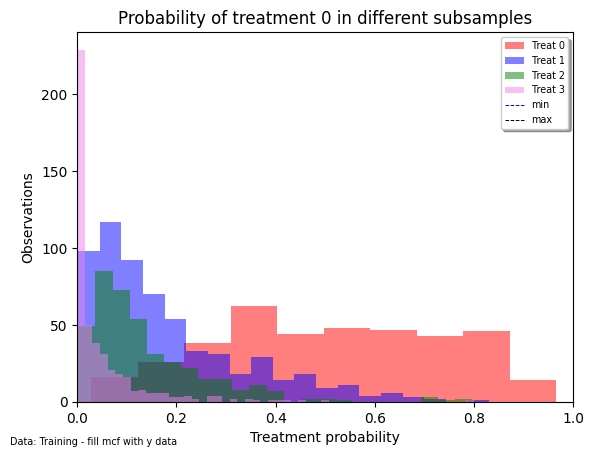

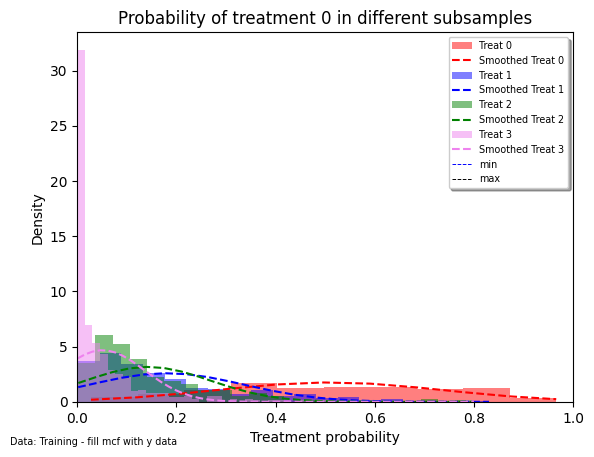

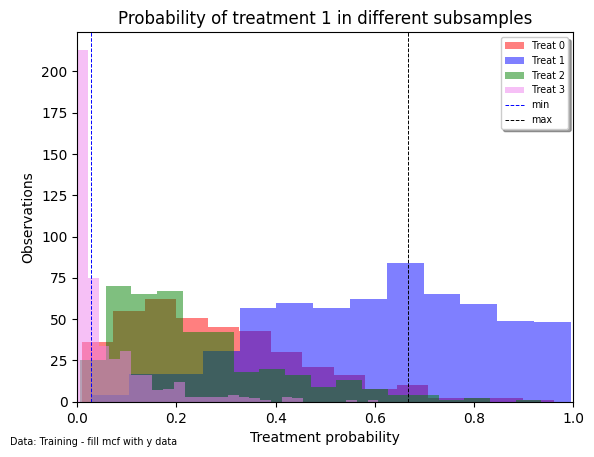

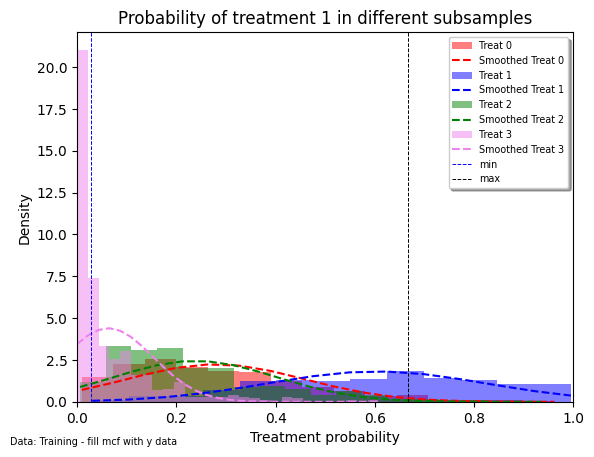

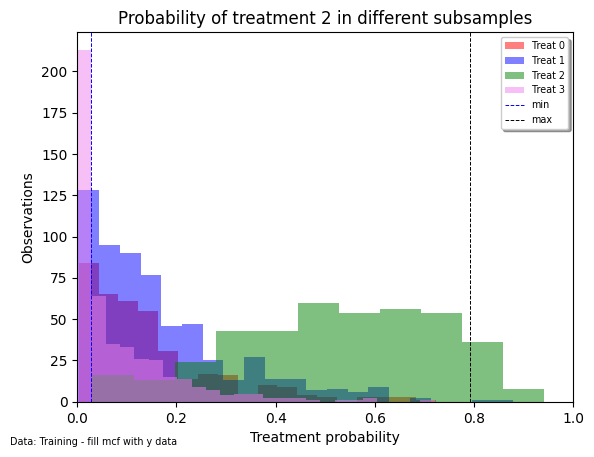

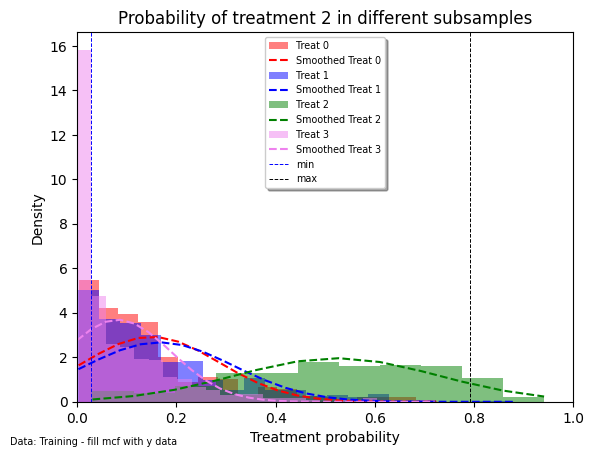

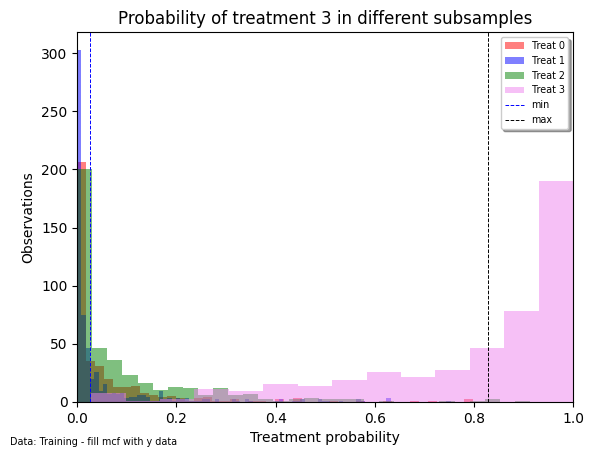

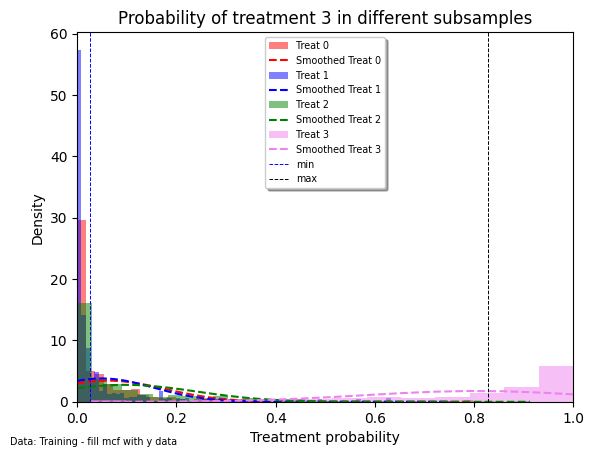


----------------------------------------------------------------------------------------------------
Data investigated for common support: Training - fill mcf with y data
----------------------------------------------------------------------------------------------------
Observations deleted: 1203 (64.37%)
----------------------------------------------------------------------------------------------------

Observations kept, by treatment
                Obs.  Share in %
v2x_regime                  
0.0          143       21.47
1.0          153       22.97
2.0          187       28.08
3.0          183       27.48
-   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   
Observations deleted, by treatment
             Obs.  Share in %
v2x_regime                  
0.0          228       18.95
1.0          431       35.83
2.0          203       16.87
3.0          341       28.35

---------------------------------------------------------------------------------------

In [98]:
# Train the Modified Causal Forest on the training data
my_mcf.train(training_df)
# Predict treatment effects using the model on prediction data
results = my_mcf.predict(prediction_df)

In [99]:
# Access the Average Treatment Effect (ATE)
ate_array = results.get('ate')
print("Average Treatment Effect (ATE):\n", ate_array)

Average Treatment Effect (ATE):
 [[[-0.18812367 -0.01484114  0.4377103   0.17328254  0.62583397
    0.45255143]]]


In [40]:
df_interpolated.groupby('v2x_regime')['gdppc'].median()
df_interpolated.groupby('v2x_regime')['log_gdppc'].median()


v2x_regime
0.0     8.238128
1.0     8.133000
2.0     8.918450
3.0    10.157369
Name: log_gdppc, dtype: float64

In [71]:
df_interpolated['v2x_regime'].value_counts()


v2x_regime
1.0    2297
0.0    1595
3.0    1527
2.0    1447
Name: count, dtype: int64

In [72]:
df_interpolated['gdppc'].describe()



count     6866.000000
mean     11977.241008
std      13447.110674
min        377.580086
25%       2179.008928
50%       6838.346347
75%      17027.741337
max      88366.219328
Name: gdppc, dtype: float64

/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_65493/2475850429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_interpolated['log_gdppc'] = np.log(df_interpolated['gdppc'])


In [20]:
df_interpolated

,country,year,gdp_pc_lag1,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,v2x_corr,v2x_execorr,v2x_pubcorr,export_share,log_gdppc
0,AFG,1970,1278.000000,223.1,0.750797,1272.000000,0.0,2.477,0.477,0.473,0.460,0.435776,7.148346
1,AFG,1971,1272.000000,220.2,0.750797,1237.000000,0.0,2.382,0.477,0.473,0.460,0.407280,7.120444
2,AFG,1972,1237.000000,217.1,0.750797,1007.000000,0.0,2.502,0.494,0.473,0.524,0.478939,6.914731
3,AFG,1973,1007.000000,213.8,0.750797,1011.000000,0.0,2.567,0.530,0.444,0.495,0.550598,6.918695
4,AFG,1974,1011.000000,210.7,0.750797,1039.000000,0.0,2.488,0.534,0.457,0.495,0.487337,6.946014
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6861,ZWE,2018,1843.946230,47.4,0.366200,1900.199191,1.0,1.518,0.762,0.769,0.796,0.318904,7.549714
6862,ZWE,2019,1900.199191,46.0,0.366200,1753.024449,1.0,1.609,0.765,0.786,0.789,0.367556,7.469098
6863,ZWE,2020,1753.024449,44.9,0.366200,1585.972804,1.0,1.709,0.795,0.772,0.795,0.384943,7.368953
6864,ZWE,2021,1585.972804,43.6,0.366200,1687.253154,1.0,1.743,0.826,0.732,0.846,0.398450,7.430857


In [46]:
from data_functions import load_capital_for, load_trade_share, load_TFP, load_hc, load_tax_rev

In [51]:
trade_share_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/trade_share_df.csv")
cap_for_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/gross_cap_for_df.csv")
hc_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/hc_df.csv")
tax_rev_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/tax_rev_df.csv")
gov_exp_df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/gov_exp_df.csv")
tfp_df = pd.read_csv('/Users/ghadaelhusseini/PyCharmMiscProject/Standardized Country names/TFP_df.csv')


In [89]:
tfp_df

,Unnamed: 0,country,year,rtfpna
0,0,ABW,1950,NaN
1,1,ABW,1951,NaN
2,2,ABW,1952,NaN
3,3,ABW,1953,NaN
4,4,ABW,1954,NaN
...,...,...,...,...
12805,12805,ZWE,2015,0.999666
12806,12806,ZWE,2016,0.980511
12807,12807,ZWE,2017,1.000000
12808,12808,ZWE,2018,1.018163


In [65]:
gov_exp_df


,Unnamed: 0,year,General government final consumption expenditure (% of GDP),country
0,0,1960,..,AFG
1,1,1960,..,ALB
2,2,1960,26.6654194665797,DZA
3,3,1960,..,ASM
4,4,1960,..,AND
...,...,...,...,...
13792,13978,2022,..,YEM
13793,13979,2022,14.4528290197612,ZMB
13794,13980,2022,16.6461897920814,ZWE
13795,13984,2022,NaN,Data from database: World Development Indicators


In [52]:
# Merge Capital Formation into main df
df = df.merge(
    cap_for_df[['country','year','Gross capital formation (% of GDP)']],
    on=['country','year'],
    how='outer'  # keeps all rows from both dfs
)



In [53]:
# Merge Gov Exp into main df
df = df.merge(
    gov_exp_df[['country','year','General government final consumption expenditure (% of GDP)']],
    on=['country','year'],
    how='outer'  # keeps all rows from both dfs
)


In [54]:
import numpy as np

# Replace ".." with NaN
df['General government final consumption expenditure (% of GDP)'] = (
    df_interpolated['General government final consumption expenditure (% of GDP)']
    .replace('..', np.nan)
)

# Ensure the column is numeric
df['General government final consumption expenditure (% of GDP)'] = pd.to_numeric(
    df['General government final consumption expenditure (% of GDP)'],
    errors='coerce'
)

In [55]:
# Merge trade_share into main df
df = df.merge(
    tax_rev_df[['country','year','Tax revenue (% of GDP)']],
    on=['country','year'],
    how='outer'  # keeps all rows from both dfs
)


In [90]:
# Merge trade_share into main df
df_interpolated = df_interpolated.merge(
    tfp_df[['country','year','rtfpna']],
    on=['country','year'],
    how='outer'  # keeps all rows from both dfs
)


In [56]:
import numpy as np

# Replace ".." with NaN
df['Tax revenue (% of GDP)'] = (
    df['Tax revenue (% of GDP)']
    .replace('..', np.nan)
)

# Ensure the column is numeric
df['Tax revenue (% of GDP)'] = pd.to_numeric(
    df['Tax revenue (% of GDP)'],
    errors='coerce'
)

In [57]:
# Merge hc into main df
df = df.merge(
    hc_df[['country','year','hc']],
    on=['country','year'],
    how='outer'  # keeps all rows from both dfs
)

Unnamed: 0.3  Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0  country  year  gdp_pc_lag1   Mortality rate, infant (per 1,000 live births)  fe_etfra  gdppc         v2x_regime  Population growth rate - Sex: all - Age: all - Variant: estimates  v2x_corr  v2x_execorr  v2x_pubcorr  export_share  Gross capital formation (% of GDP)  General government final consumption expenditure (% of GDP)  Tax revenue (% of GDP)  hc      
74.0          361.0         199.0         199.0       AGO      2002  2162.485019   108.1                                           0.756100  2522.671861   0.0         3.435                                                              0.840     0.880        0.854        0.761047      30.493173                           19.130579                                                    15.532812               1.320135    1
4337.0        11224.0       11062.0       13596.0     MUS      2014  17555.554166  13.0                                            0.631531  18192.187474  2.0         

In [66]:
df.nunique()

Unnamed: 0.3                                                         6866
Unnamed: 0.2                                                         6866
Unnamed: 0.1                                                         6866
Unnamed: 0                                                           6866
country                                                               269
year                                                                   75
gdp_pc_lag1                                                          6455
Mortality rate, infant (per 1,000 live births)                       1449
fe_etfra                                                              145
gdppc                                                                6485
v2x_regime                                                              4
Population growth rate - Sex: all - Age: all - Variant: estimates    3760
v2x_corr                                                              878
v2x_execorr                           

In [ ]:
# First Filter from the year 2000 - 2023 and largest countries possible


In [12]:
df_interpolated = df_interpolated.drop(
    columns=[
        'gdp_pc_lag1',
        'v2x_corr',
        'v2x_execorr',
        'v2x_pubcorr',
        "Mortality rate, infant (per 1,000 live births)"
    ]
)

KeyError: "['gdp_pc_lag1', 'v2x_corr', 'v2x_execorr', 'v2x_pubcorr'] not found in axis"

In [13]:
df_interpolated = df_interpolated.drop(
    columns=[
        "Mortality rate, infant (per 1,000 live births)"
    ]
)

In [17]:
df_new = df_interpolated

In [15]:
len(df_interpolated)

16926

In [18]:
df_new.to_csv('df_new.csv', index=False)

In [96]:
df_new

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,country,year,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),hc,Tax revenue (% of GDP),General government final consumption expenditure (% of GDP),rtfpna
0,NaN,NaN,NaN,NaN,ABW,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,ABW,1951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,ABW,1952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,ABW,1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,ABW,1954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18991,6863.0,18137.0,17931.0,20856.0,ZWE,2020,44.9,0.3662,1585.972804,1.0,1.709,0.384943,13.146075,NaN,NaN,8.867855,NaN
18992,6864.0,18138.0,17932.0,20857.0,ZWE,2021,43.6,0.3662,1687.253154,1.0,1.743,0.398450,15.507058,NaN,NaN,14.915906,NaN
18993,6865.0,18139.0,17933.0,20858.0,ZWE,2022,42.2,0.3662,1703.529373,1.0,1.670,0.402938,14.610339,NaN,NaN,16.646190,NaN
18994,NaN,NaN,NaN,NaN,ZWE,2023,NaN,NaN,NaN,NaN,NaN,NaN,16.274040,NaN,NaN,NaN,NaN


In [97]:
cols = [
    'Gross capital formation (% of GDP)',
    'hc',
    'Tax revenue (% of GDP)',
    'General government final consumption expenditure (% of GDP)',
    'rtfpna',

]

nan_counts = df_new[cols].isna().sum()

print(nan_counts)
print("\nColumn with most NaNs:", nan_counts.idxmax())


Gross capital formation (% of GDP)                              9057
hc                                                             10359
Tax revenue (% of GDP)                                         14501
General government final consumption expenditure (% of GDP)    10688
rtfpna                                                         12584
dtype: int64

Column with most NaNs: Tax revenue (% of GDP)


In [20]:
df_new = df_new.loc[:, ~df_new.columns.str.startswith('Unnamed')]


In [21]:
df_new

,country,year,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,General government final consumption expenditure (% of GDP),Gross capital formation (% of GDP)
0,ABW,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
16921,ZWE,2020,0.3662,1585.972804,1.0,1.709,0.384943,8.867855,13.146075
16922,ZWE,2021,0.3662,1687.253154,1.0,1.743,0.398450,14.915906,15.507058
16923,ZWE,2022,0.3662,1703.529373,1.0,1.670,0.402938,16.646190,14.610339
16924,ZWE,2023,NaN,NaN,NaN,NaN,NaN,NaN,16.274040


In [27]:
import pandas as pd
df_new = pd.read_csv('df_new.csv')

In [32]:
df_new

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,country,year,"Mortality rate, infant (per 1,000 live births)",fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),hc,Tax revenue (% of GDP),General government final consumption expenditure (% of GDP),rtfpna
0,NaN,NaN,NaN,NaN,ABW,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,ABW,1951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,ABW,1952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,ABW,1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,ABW,1954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18991,6863.0,18137.0,17931.0,20856.0,ZWE,2020,44.9,0.3662,1585.972804,1.0,1.709,0.384943,13.146075,NaN,NaN,8.867855,NaN
18992,6864.0,18138.0,17932.0,20857.0,ZWE,2021,43.6,0.3662,1687.253154,1.0,1.743,0.398450,15.507058,NaN,NaN,14.915906,NaN
18993,6865.0,18139.0,17933.0,20858.0,ZWE,2022,42.2,0.3662,1703.529373,1.0,1.670,0.402938,14.610339,NaN,NaN,16.646190,NaN
18994,NaN,NaN,NaN,NaN,ZWE,2023,NaN,NaN,NaN,NaN,NaN,NaN,16.274040,NaN,NaN,NaN,NaN


In [22]:
required_vars = [
   # 'Mortality rate, infant (per 1,000 live births)',
    'fe_etfra',
    'gdppc',
    'v2x_regime',
    'Population growth rate - Sex: all - Age: all - Variant: estimates',
    'export_share',
    'Gross capital formation (% of GDP)',
  #  'hc',
    #'Tax revenue (% of GDP)',
    'General government final consumption expenditure (% of GDP)',
    #'rtfpna',

]

In [23]:
def trim_country_panel(df_new, country_col='country', year_col='year', vars_required=None):
    trimmed_dfs = []

    for country, g in df_new.groupby(country_col):
        g = g.sort_values(year_col)

        # Rows where ALL required variables are present
        valid = g[vars_required].notna().all(axis=1)

        # If no fully valid rows → drop country
        if not valid.any():
            continue

        # First and last year with full data
        first_year = g.loc[valid, year_col].min()
        last_year  = g.loc[valid, year_col].max()

        # Keep only that window
        g_trimmed = g[
            (g[year_col] >= first_year) &
            (g[year_col] <= last_year)
        ]

        # 🔑 THIS LINE enforces variable dropping
        g_trimmed = g_trimmed[[country_col, year_col] + vars_required]

        trimmed_dfs.append(g_trimmed)

    return pd.concat(trimmed_dfs, ignore_index=True)


In [24]:
df_trimmed = trim_country_panel(
    df_new,
    country_col='country',
    year_col='year',
    vars_required=required_vars
)


In [34]:
len(df_trimmed)

5907

In [35]:
df_trimmed

,country,year,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP)
0,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.027203,22.109219
1,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.034015,22.109219
2,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219
3,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.194224,22.109219
4,AFG,2021,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384
...,...,...,...,...,...,...,...,...,...
5902,ZWE,2018,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162
5903,ZWE,2019,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150
5904,ZWE,2020,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855
5905,ZWE,2021,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906


In [36]:
#************************************#
# Data Interpolation - Linear Method #
#************************************#

import pandas as pd



df = df_trimmed.sort_values(["country", "year"])

# variables to interpolate
vars_to_interp = df_trimmed.columns.difference(["country", "year"])

df_new = (
    df
    .groupby("country", group_keys=False)
    .apply(lambda x: x.assign(
        **{col: x[col].interpolate(method="linear", limit_direction="both")
           for col in vars_to_interp}
    ))
)

/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_39663/2013549459.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(


In [29]:
# Data Interpolation check
df_new[df_new["country"] == "GIN"]

,country,year,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,General government final consumption expenditure (% of GDP),Gross capital formation (% of GDP)
5733,GIN,1960,0.6691,795.000000,0.0,1.835,0.435082,7.847303,10.239545
5734,GIN,1961,0.6691,795.000000,0.0,1.835,0.435082,7.847303,10.239545
5735,GIN,1962,0.6691,795.000000,0.0,1.835,0.435082,7.847303,10.239545
5736,GIN,1963,0.6691,795.000000,0.0,1.835,0.435082,7.847303,10.239545
5737,GIN,1964,0.6691,795.000000,0.0,1.835,0.435082,7.847303,10.239545
...,...,...,...,...,...,...,...,...,...
5793,GIN,2020,0.6691,1726.508255,1.0,2.527,0.586846,17.413224,31.516401
5794,GIN,2021,0.6691,1769.862325,1.0,2.485,0.637196,17.482031,16.076271
5795,GIN,2022,0.6691,1809.266567,0.0,2.480,0.584931,17.120821,14.014222
5796,GIN,2023,0.6691,1809.266567,0.0,2.480,0.584931,17.120821,23.426990


In [37]:
df_new['log_gdppc'] = np.log(df_new['gdppc'])
df_new

,country,year,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP),log_gdppc
0,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.027203,22.109219,7.564474
1,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.034015,22.109219,7.564474
2,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,7.564474
3,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.194224,22.109219,7.564474
4,AFG,2021,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,7.303538
...,...,...,...,...,...,...,...,...,...,...
5902,ZWE,2018,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162,7.549714
5903,ZWE,2019,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150,7.469098
5904,ZWE,2020,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,7.368953
5905,ZWE,2021,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906,7.430857


In [38]:
# Save the final data Interpolated as csv

df_new.to_csv("df_new.csv", index=False)

In [45]:
df_new

,country,year,fe_etfra,gdppc,v2x_regime,Population growth rate - Sex: all - Age: all - Variant: estimates,export_share,Gross capital formation (% of GDP),General government final consumption expenditure (% of GDP),log_gdppc
0,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.027203,22.109219,7.564474
1,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.034015,22.109219,7.564474
2,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,11.500000,22.109219,7.564474
3,AFG,2020,0.750797,1928.454683,1.0,3.272,0.106192,25.194224,22.109219,7.564474
4,AFG,2021,0.750797,1485.547006,1.0,1.462,0.129788,13.000000,21.262384,7.303538
...,...,...,...,...,...,...,...,...,...,...
5902,ZWE,2018,0.366200,1900.199191,1.0,1.518,0.318904,14.148444,10.374162,7.549714
5903,ZWE,2019,0.366200,1753.024449,1.0,1.609,0.367556,13.799402,7.339150,7.469098
5904,ZWE,2020,0.366200,1585.972804,1.0,1.709,0.384943,13.146075,8.867855,7.368953
5905,ZWE,2021,0.366200,1687.253154,1.0,1.743,0.398450,15.507058,14.915906,7.430857


In [50]:
df = pd.read_csv("/Users/ghadaelhusseini/PyCharmMiscProject/Final_df.csv")